# Study 6: CO₂ Emissions and Population 

Are there patterns between national population size and emissions when using logarithmic scale?

### Objective:

To investigate whether there's a pattern between national population size and CO₂ emissions

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader

## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [4]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head()

,Continent,Country,year,co2,gdp,population,total_gdp,total_co2
0,Africa,Algeria,1800,0.0,763.0,2500000.0,1.907500e+09,0.0
1,Africa,Algeria,1801,0.0,764.0,2510000.0,1.917640e+09,0.0
2,Africa,Algeria,1802,0.0,765.0,2520000.0,1.927800e+09,0.0
3,Africa,Algeria,1803,0.0,766.0,2530000.0,1.937980e+09,0.0
4,Africa,Algeria,1804,0.0,767.0,2540000.0,1.948180e+09,0.0


## Plot: CO₂ and Population (2020)
Visualizing the correlation between  CO₂ emissions and Population for the year 2020.

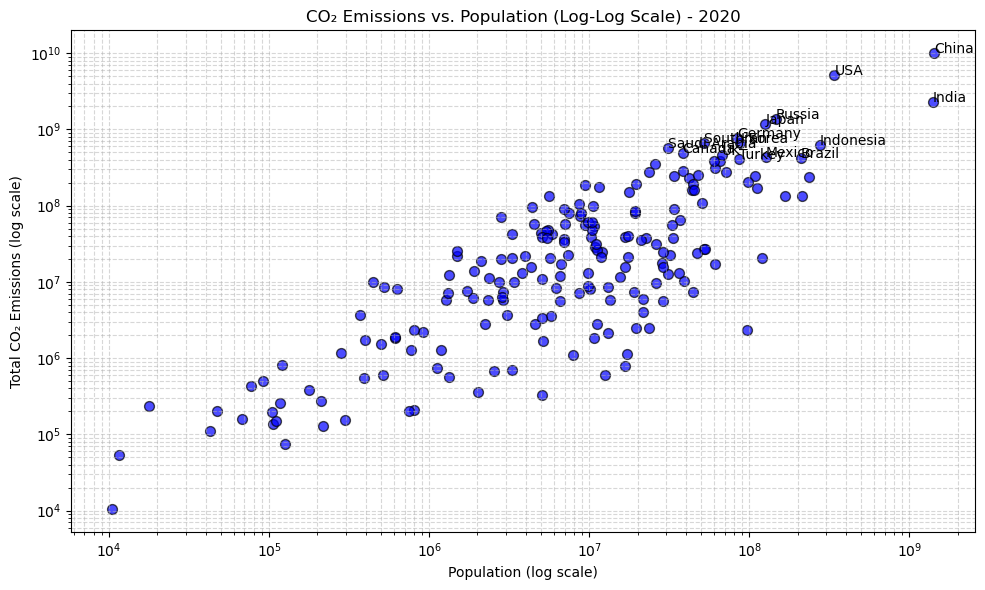

In [6]:
# Define the year and number of countries to display
year_filter = 2020



# Filter and prepare the data
df_year = data[data["year"] == year_filter].copy()

# Drop missing or invalid values
df_year = df_year.dropna(subset=["co2", "gdp"])
df_year = df_year.replace([np.inf, -np.inf], np.nan)
df_year = df_year.dropna(subset=["co2", "gdp"])

# Create scatter plot with log scales
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_year["population"],
    df_year["total_co2"],
    alpha=0.7,
    c='blue',
    edgecolors='k',
    s=50
)

# Annotate countries (optional: show only top emitters or sampled subset to avoid clutter)
for i, row in df_year.nlargest(15, "total_co2").iterrows():
    plt.annotate(row["Country"], (row["population"], row["total_co2"]), fontsize=10)

# Log scales
plt.xscale("log")
plt.yscale("log")

# Labels and title
plt.xlabel("Population (log scale)")
plt.ylabel("Total CO₂ Emissions (log scale)")
plt.title(f"CO₂ Emissions vs. Population (Log-Log Scale) - {year_filter}")
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



### Key Observations:

**Strong correlation:** There appears to be a strong positive correlation between population and total CO2 emissions. Countries with larger populations tend to have higher total CO2 emissions, and conversely, countries with smaller populations generally have lower total CO2 emissions.

**Spread and Variability:** The spread around the trend line highlights that population is not the only factor





